# Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from tensorflow.keras.utils import to_categorical
import os
import itertools
from random import randint

In [2]:
base_dir='Data'
LABELS=os.listdir(base_dir)
LABELS.sort()
LABELS

['Fake', 'Real']

In [3]:
data=np.load('dataset/data.npz')
X=data['x']/255 #data normalisation
Y=data['y'] #label

In [4]:
print(X.shape,Y.shape)

(2041, 128, 128, 3) (2041, 2)


# Data Spliting

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=101,shuffle=True)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(1632, 128, 128, 3) (409, 128, 128, 3) (1632, 2) (409, 2)


##  Visualisation

<p> Visualizing random images of train</p>

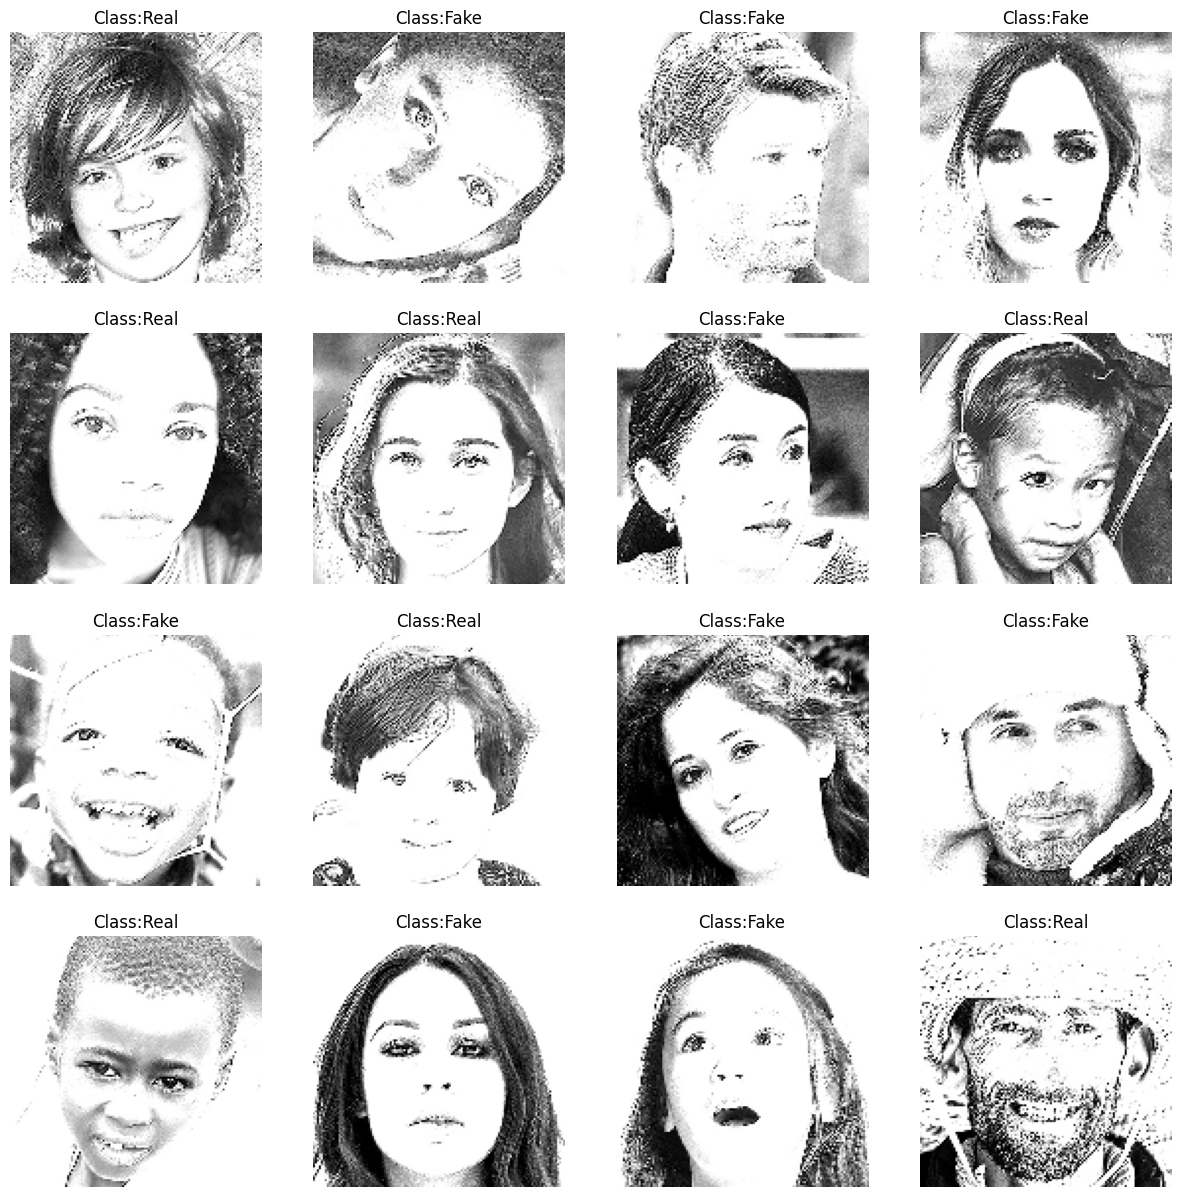

In [7]:
def show_images(X,y):
    labels =["Fake","Real"]
    x,y = X,y
    plt.figure(figsize=(15, 15))
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        idx = randint(0, X_train.shape[0]-1)
        plt.imshow(x[idx])
        plt.axis("off")
        plt.title("Class:{}".format(LABELS[int(y[idx][0])]))
show_images(X_train,y_train)

<p> Visualising random images of test </p>

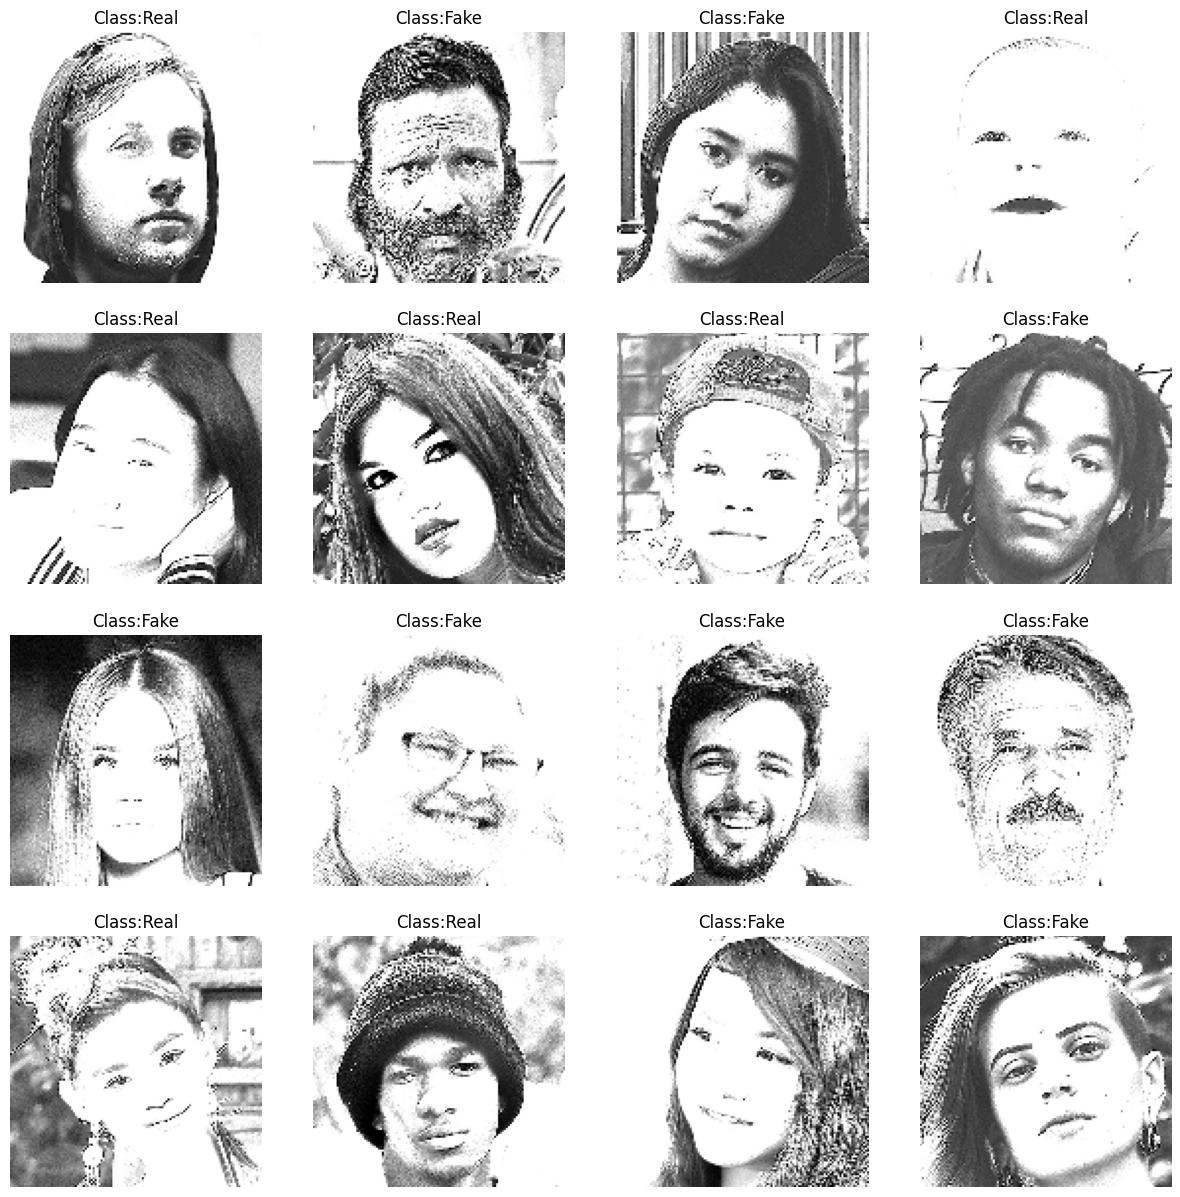

In [8]:
def show_images(X,y):
    labels =["Fake","Real"]
    x,y = X,y
    plt.figure(figsize=(15, 15))
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        idx = randint(0, X_test.shape[0]-1)
        plt.imshow(x[idx])
        plt.axis("off")
        plt.title("Class:{}".format(LABELS[int(y[idx][0])]))
show_images(X_test,y_test)

In [13]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [16]:
model = Sequential()

model.add(Conv2D(70, (3,3), activation='relu', padding='same', input_shape=(128, 128, 3))) #extract features
model.add(MaxPooling2D(pool_size=(2, 2))) #reduce the number of parameters when the images are too large
model.add(BatchNormalization())

model.add(Conv2D(20, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model.add(Conv2D(10, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model.add(Dropout(0.6))

model.add(Flatten())#matrix is converted into one dimension

model.add(Dense(512, activation="relu")) 

model.add(Dropout(0.3))

model.add(Dense(2, activation="sigmoid"))

In [18]:
adam = Adam(lr=0.0001, decay=1e-06) #reduces step size
model.compile(
    loss='binary_crossentropy', #loss function used for single label categorization.only one category is applicable for all data point
    optimizer=adam,
    metrics=['accuracy']
)

C:\Users\Kiran\anaconda31\envs\myenv\lib\site-packages\keras\optimizer_v2\adam.py:105: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


In [19]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 128, 128, 70)      1960      
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 64, 64, 70)       0         
 2D)                                                             
                                                                 
 batch_normalization_6 (Batc  (None, 64, 64, 70)       280       
 hNormalization)                                                 
                                                                 
 conv2d_7 (Conv2D)           (None, 64, 64, 20)        12620     
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 32, 32, 20)       0         
 2D)                                                             
                                                      

In [28]:
hist = model.fit(x = X_train ,y = y_train, batch_size = 65, epochs = 20, validation_data = (X_test, y_test),shuffle=True)

Epoch 1/20
26/26 [==============================] - 13s 459ms/step - loss: 1.0589 - accuracy: 0.5214 - val_loss: 0.6921 - val_accuracy: 0.5281
Epoch 2/20
26/26 [==============================] - 11s 418ms/step - loss: 0.9352 - accuracy: 0.5846 - val_loss: 0.6921 - val_accuracy: 0.5403
Epoch 3/20
26/26 [==============================] - 11s 418ms/step - loss: 0.8671 - accuracy: 0.6164 - val_loss: 0.6968 - val_accuracy: 0.5403
Epoch 4/20
26/26 [==============================] - 11s 419ms/step - loss: 0.8494 - accuracy: 0.6281 - val_loss: 0.7200 - val_accuracy: 0.5403
Epoch 5/20
26/26 [==============================] - 11s 426ms/step - loss: 0.8051 - accuracy: 0.6336 - val_loss: 0.7266 - val_accuracy: 0.5403
Epoch 6/20
26/26 [==============================] - 11s 431ms/step - loss: 0.7650 - accuracy: 0.6569 - val_loss: 0.7341 - val_accuracy: 0.5403
Epoch 7/20
26/26 [==============================] - 11s 431ms/step - loss: 0.7448 - accuracy: 0.6556 - val_loss: 0.7491 - val_accuracy: 0.5403

In [29]:
hist = model.fit(x = X ,y = Y, batch_size = 65, epochs = 20, validation_data = (X_test, y_test),shuffle=True)

Epoch 1/20
32/32 [==============================] - 15s 452ms/step - loss: 0.6054 - accuracy: 0.7173 - val_loss: 0.6542 - val_accuracy: 0.6210
Epoch 2/20
32/32 [==============================] - 13s 419ms/step - loss: 0.5771 - accuracy: 0.7491 - val_loss: 0.6170 - val_accuracy: 0.6381
Epoch 3/20
32/32 [==============================] - 13s 416ms/step - loss: 0.5837 - accuracy: 0.7242 - val_loss: 0.6054 - val_accuracy: 0.6699
Epoch 4/20
32/32 [==============================] - 13s 418ms/step - loss: 0.5682 - accuracy: 0.7452 - val_loss: 0.5735 - val_accuracy: 0.6870
Epoch 5/20
32/32 [==============================] - 14s 423ms/step - loss: 0.5413 - accuracy: 0.7521 - val_loss: 0.5444 - val_accuracy: 0.7213
Epoch 6/20
32/32 [==============================] - 13s 421ms/step - loss: 0.5391 - accuracy: 0.7658 - val_loss: 0.5557 - val_accuracy: 0.7139
Epoch 7/20
32/32 [==============================] - 14s 423ms/step - loss: 0.5343 - accuracy: 0.7585 - val_loss: 0.5057 - val_accuracy: 0.7628

##  Accuracy and Loss Plot Graphs

In [32]:
model.save("model/cnn_model_weights.h5")

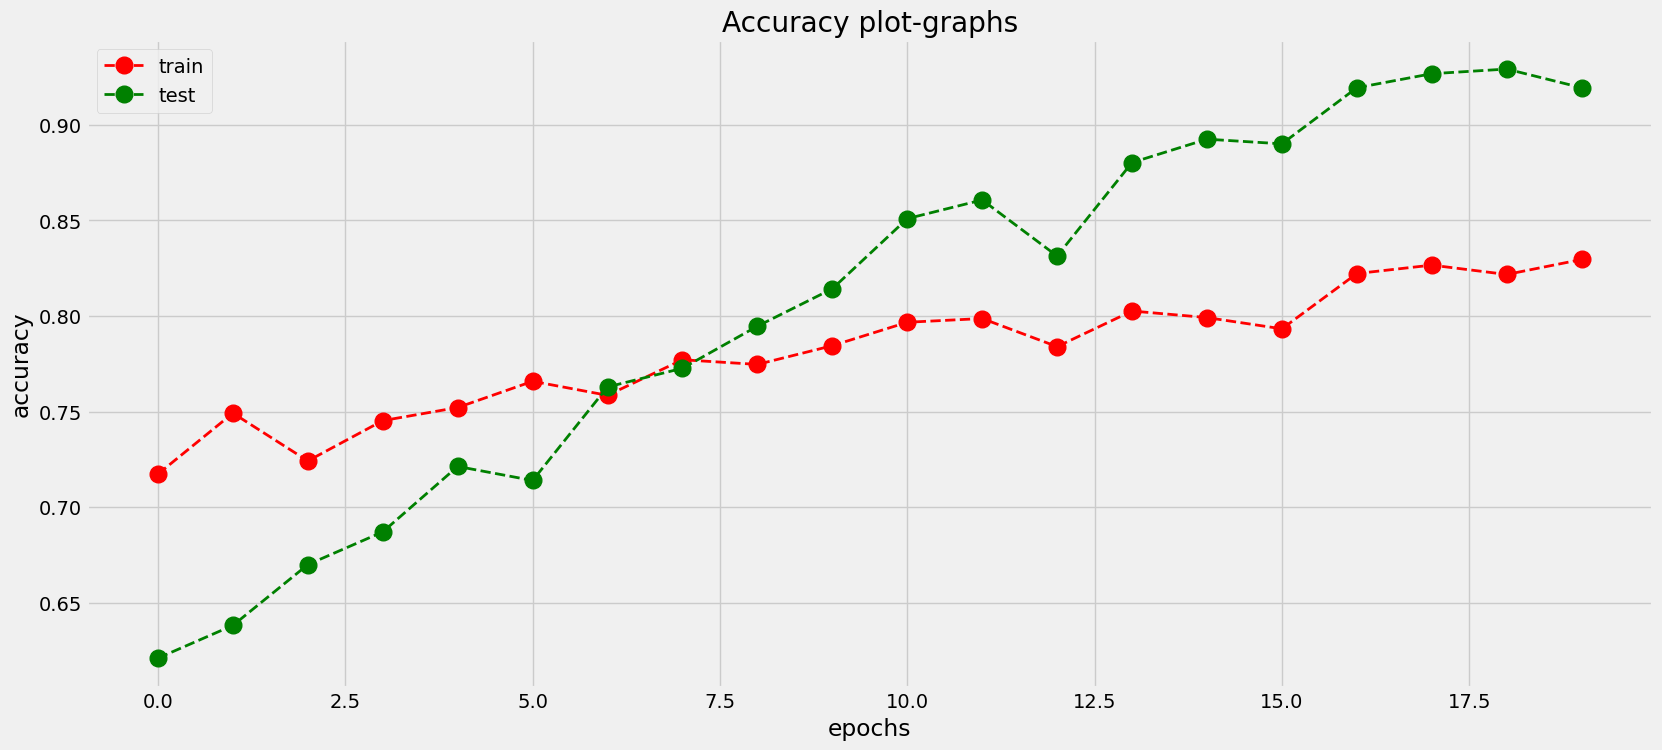

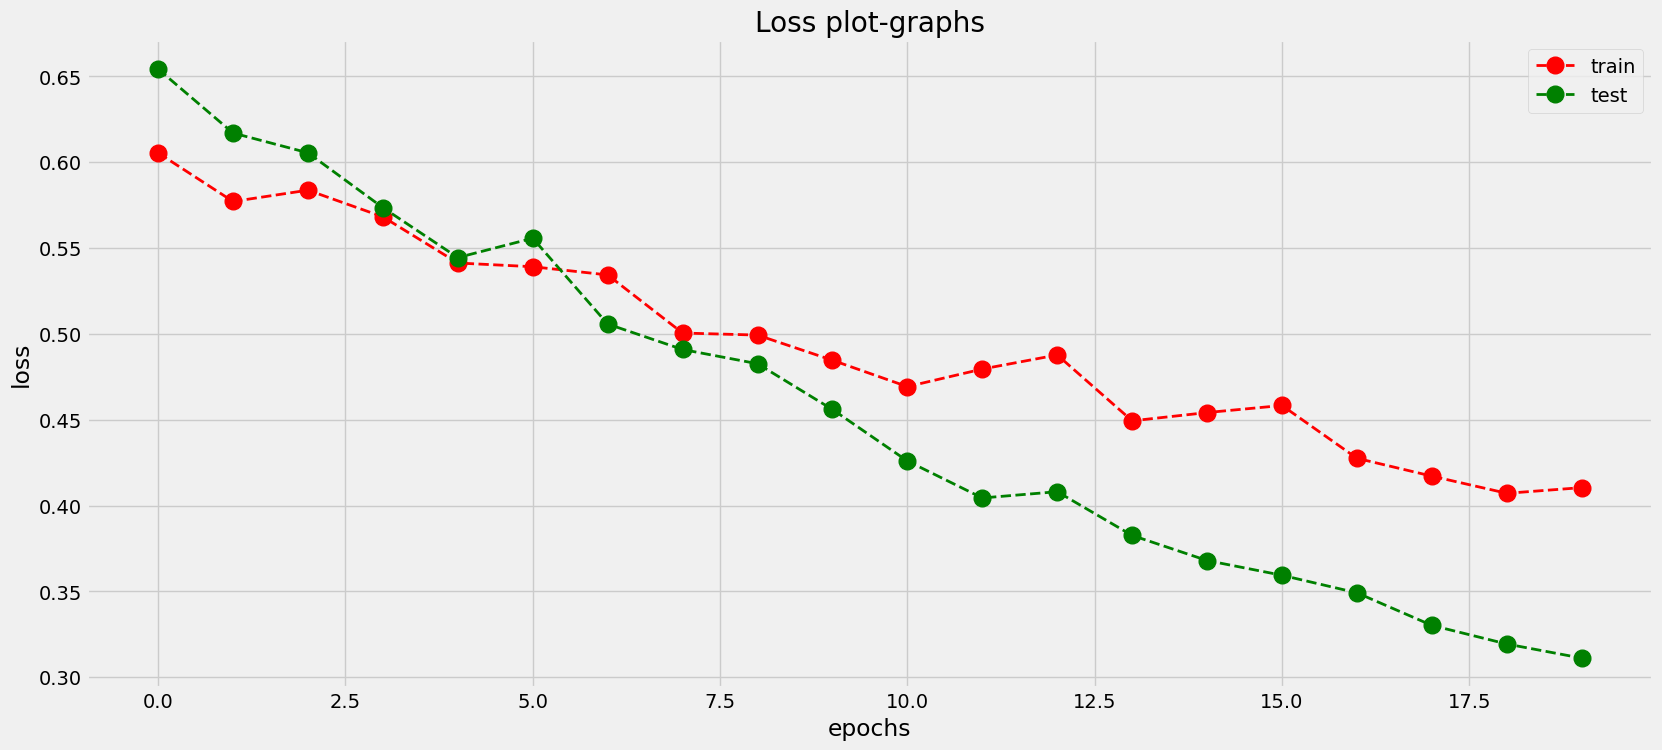

In [33]:
with plt.style.context(style="fivethirtyeight"):
    plt.figure(figsize=(18,8))
    plt.plot(hist.history['accuracy'],color="red",marker="o",linestyle='dashed',linewidth=2, markersize=12)
    plt.plot(hist.history['val_accuracy'],color="green",marker="o",linestyle='dashed',linewidth=2, markersize=12)
    plt.title('Accuracy plot-graphs')
    plt.ylabel('accuracy')
    plt.xlabel('epochs')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

    plt.figure(figsize=(18,8))
    plt.plot(hist.history['loss'],color="red",marker="o",linestyle='dashed',linewidth=2, markersize=12)
    plt.plot(hist.history['val_loss'],color="green",marker="o",linestyle='dashed',linewidth=2, markersize=12)
    plt.title('Loss plot-graphs')
    plt.ylabel('loss')
    plt.xlabel('epochs')
    plt.legend(['train', 'test'], loc='upper right')
    plt.show()

In [34]:
test_pred = model.predict(X_test,batch_size=64,verbose=1)

7/7 [==============================] - 1s 82ms/step


In [35]:
print(test_pred)

[[0.65484524 0.52801657]
 [0.8025625  0.2814005 ]
 [0.49202824 0.43284494]
 [0.8048706  0.15693986]
 [0.05141068 0.9604514 ]
 [0.81016636 0.30376214]
 [0.48653457 0.5043247 ]
 [0.4265886  0.53444433]
 [0.26649514 0.63382995]
 [0.16130495 0.8092401 ]
 [0.28516382 0.5721188 ]
 [0.9135237  0.10114104]
 [0.27996132 0.74122906]
 [0.02482593 0.9634639 ]
 [0.20049998 0.7972957 ]
 [0.05592853 0.9151409 ]
 [0.9037894  0.1700527 ]
 [0.5781007  0.4004935 ]
 [0.19397518 0.7344044 ]
 [0.77385795 0.18187585]
 [0.7165065  0.23719889]
 [0.68992007 0.28510332]
 [0.2286801  0.7606827 ]
 [0.81519926 0.1353412 ]
 [0.7131099  0.1813882 ]
 [0.3971585  0.49156705]
 [0.19174525 0.6879236 ]
 [0.08391169 0.8304215 ]
 [0.8716856  0.1479527 ]
 [0.86158955 0.12641928]
 [0.42823085 0.57914525]
 [0.56553996 0.41741192]
 [0.16633436 0.8796366 ]
 [0.24399987 0.743034  ]
 [0.17676279 0.8197302 ]
 [0.4571792  0.44957212]
 [0.8567419  0.16544795]
 [0.21829456 0.76247215]
 [0.20902508 0.6871822 ]
 [0.02707088 0.9824289 ]


In [36]:
predictions = []
for p in test_pred:
    result = np.argmax(p)      
    predictions += [result]

In [37]:
print(len(predictions))

409


In [38]:
print(predictions)

[0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 

In [39]:
print(y_test)

[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 

In [40]:
true = []
for p in y_test:
    result = np.argmax(p)      
    true += [result]

In [41]:
print(len(true))

409


In [42]:
print(predictions)

[0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 

In [43]:
true = []
for p in y_test:
    result = np.argmax(p)      
    true += [result]

In [44]:
print(len(true))

409


In [45]:
print(true)

[0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 

# Result Analysis

## Accuracy Score

In [46]:
accuracy = accuracy_score(true, predictions)
print(f"CNN Model Validated Accuracy is: {accuracy*100:.2f}%")

CNN Model Validated Accuracy is: 91.93%


In [47]:
print(classification_report(y_true=true,y_pred=predictions,target_names=LABELS))

              precision    recall  f1-score   support

        Fake       0.92      0.90      0.91       188
        Real       0.92      0.93      0.93       221

    accuracy                           0.92       409
   macro avg       0.92      0.92      0.92       409
weighted avg       0.92      0.92      0.92       409



# Confusion Matrix

In [48]:
def plot_confusion_matrix(cm, classes,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    plt.figure(figsize=(5,5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

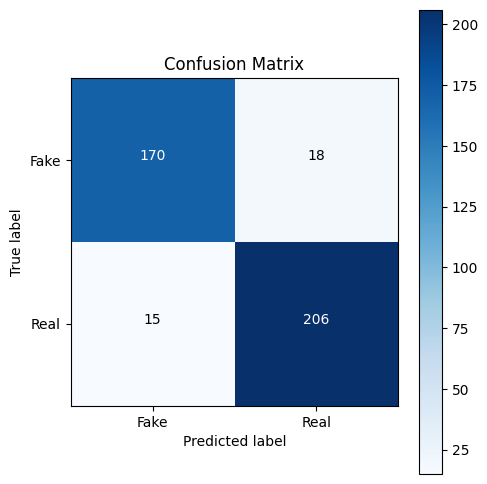

In [49]:
cm = confusion_matrix(y_true=true, y_pred=predictions)
plot_confusion_matrix(cm, LABELS, title='Confusion Matrix')